## Goal: Segment customers into groups based on their behavior and identify which groups are more likely to contain customers at risk of churn.

## Problem Statements:


*   Which types of customers exist?
*   Which customer segment is most valuable?
*   Which segment shows high support calls/payment delays?
*   Which segment contains more churned customers?
*   What actions should the company take for each segment?







In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load The Dataset

In [2]:
df = pd.read_csv('/content/ecommerce_customer_data_custom_ratios.csv')

In [3]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [4]:
df.shape

(250000, 13)

In [5]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [8]:
df = df.drop('Customer ID',axis = 1)

## Understand The Data

In [9]:
df.describe()

,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [10]:
df.isnull().sum()

,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47596
Customer Name,0
Age,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

,0
Purchase Date,249736
Product Category,4
Product Price,491
Quantity,5
Total Purchase Amount,5247
Payment Method,4
Customer Age,53
Returns,2
Customer Name,39920
Age,53


In [13]:
df.select_dtypes(include='object').columns

Index(['Purchase Date', 'Product Category', 'Payment Method', 'Customer Name',
       'Gender'],
      dtype='object')

## EDA

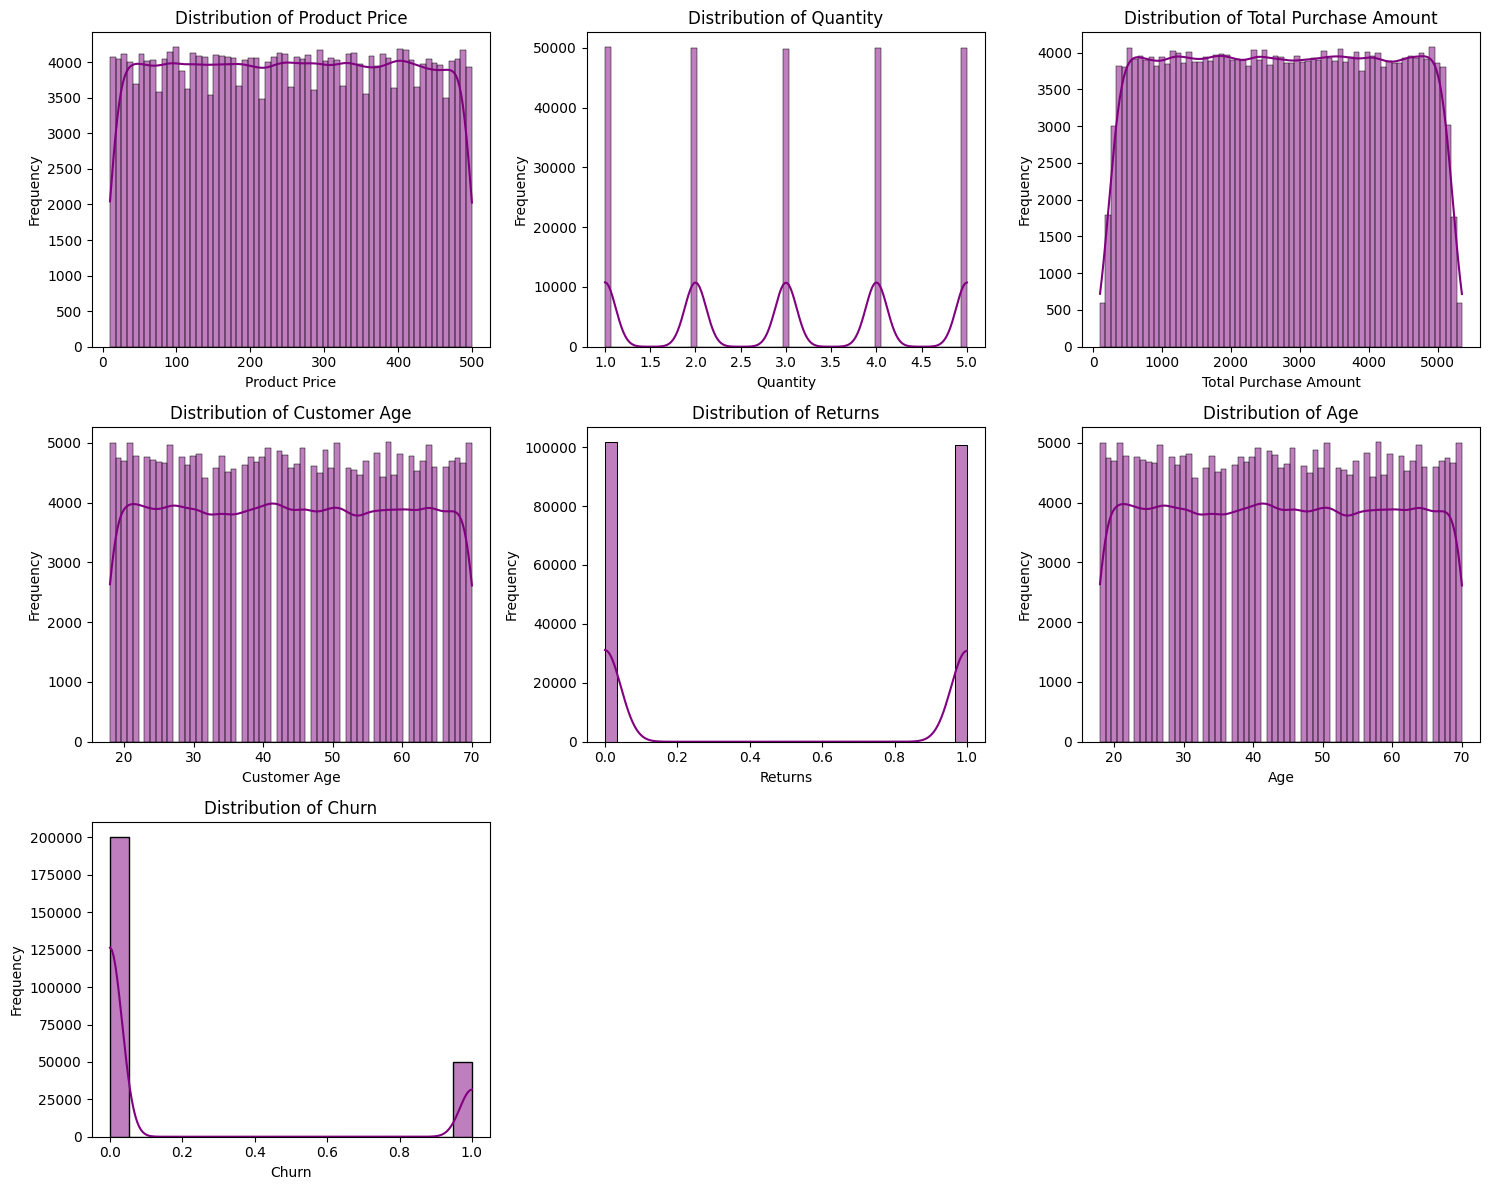

In [14]:
numeric_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i],color = 'purple')

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove empty subplots
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

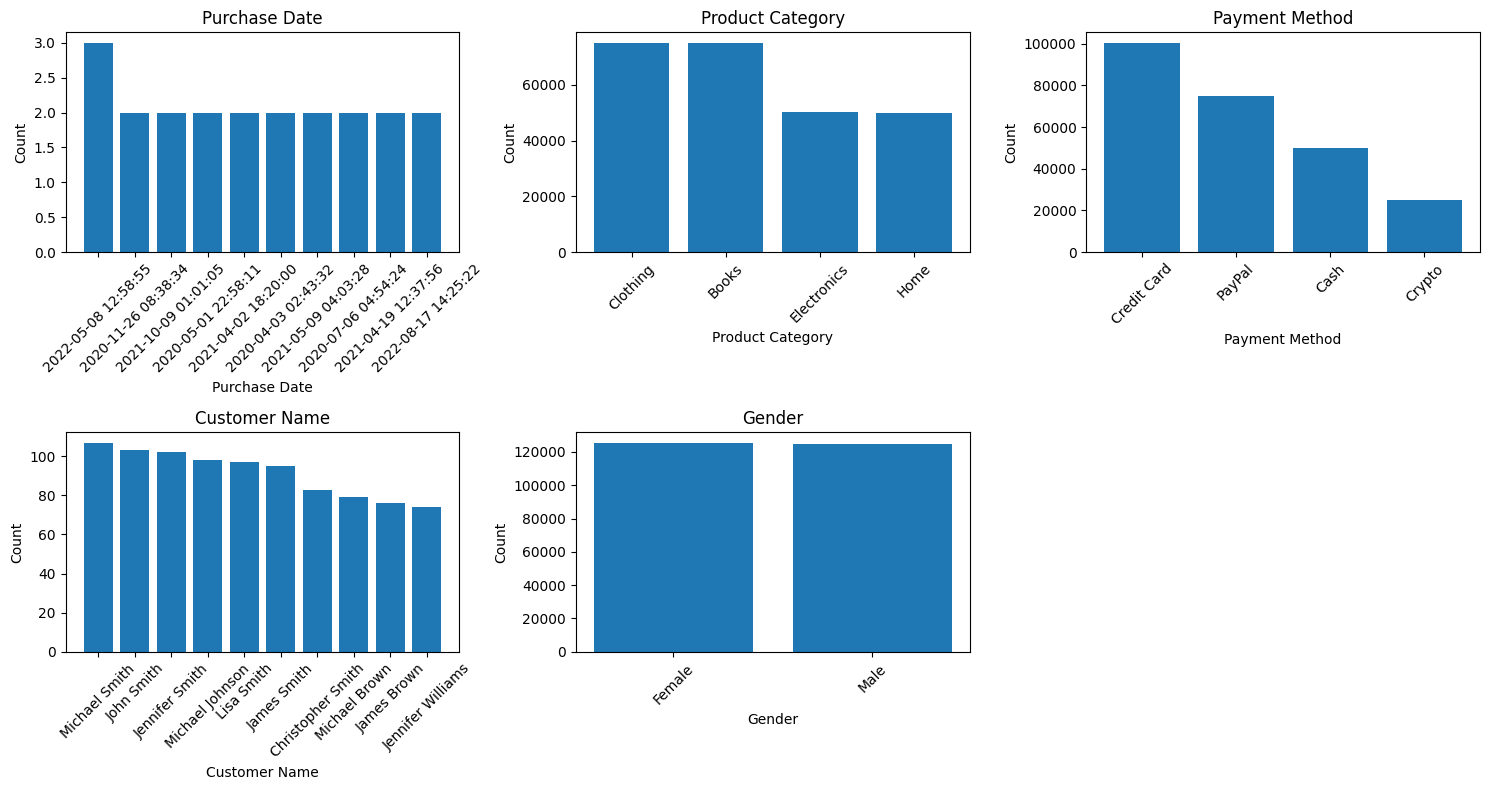

In [16]:
categorical_cols = df.select_dtypes(include='object').columns

n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    # Count categories
    counts = df[col].value_counts().head(10)

    # Plot
    axes[i].bar(counts.index.astype(str), counts.values)

    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    axes[i].tick_params(axis='x', rotation=45)

# Remove unused axes
for i in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

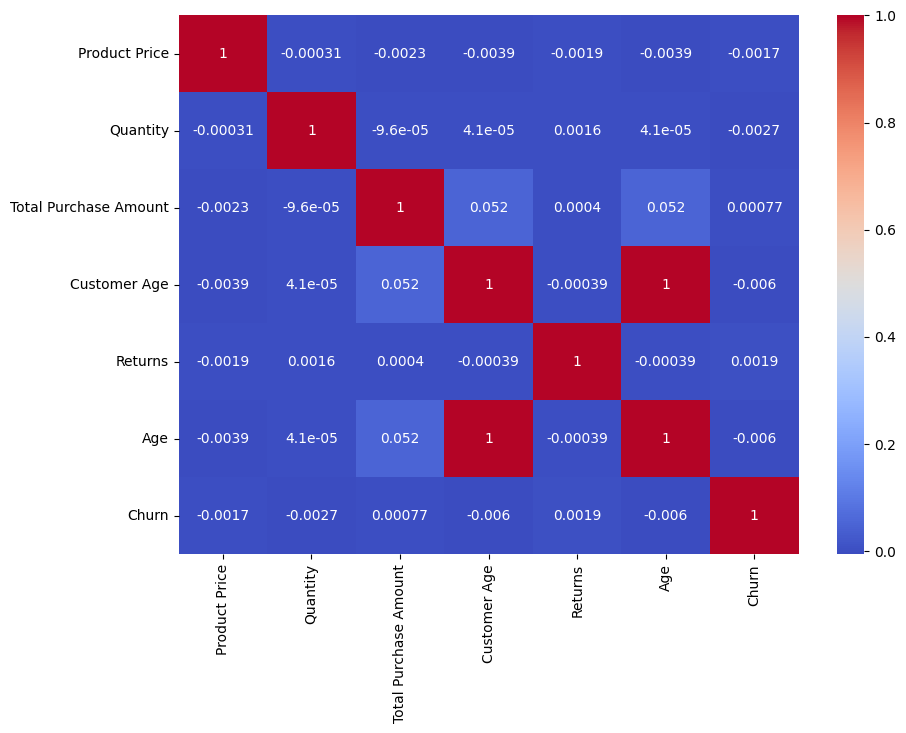

In [15]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [17]:
df['Churn'].value_counts()


,count
Churn,
0,200126
1,49874
